In [1]:
import torch
import random
from torch import nn
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path

Random image path: ../dataset_with_label/train/with_tumor/Image3580.jpg
Image label: with_tumor
Image height: 240
Image width: 240


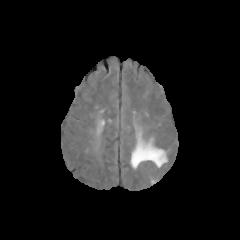

In [2]:
# set a random seed
random.seed(42)

data_path = Path("../dataset_with_label/")
# get the list of image path
image_path_list = list(data_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)

# get image label from path name
image_label = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image label: {image_label}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

In [3]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

In [4]:
# do the data transform process
data_transform = transforms.Compose([
  transforms.Resize(size=(64, 64)),
  # convert the image to tensor
  transforms.ToTensor()
])

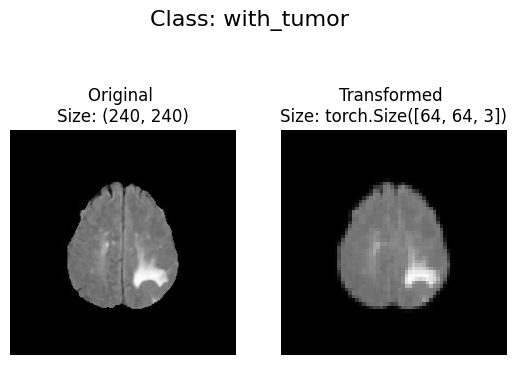

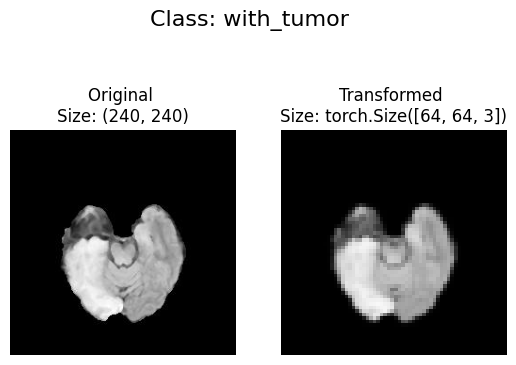

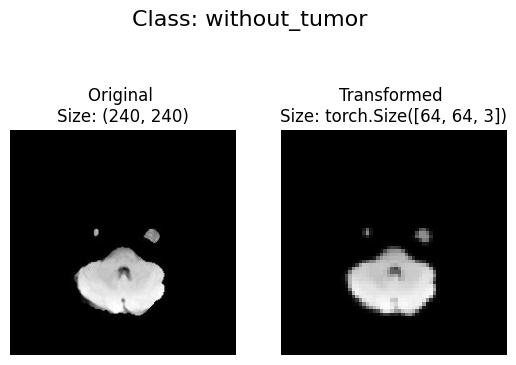

In [5]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f) 
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib 
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0) 
            ax[1].imshow(transformed_image) 
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list, 
                        transform=data_transform, 
                        n=3)

In [6]:
# create the train and test dataset by using ImageFolder
train_data = datasets.ImageFolder(
  root=data_path / "train",
  transform=data_transform
)

test_data = datasets.ImageFolder(
  root=data_path / "test",
  transform=data_transform
)

print(f"Train data:\n{train_data}\n\n")
print(f"Test data:\n{test_data}")
print(f"Images in train data:{len(train_data)} \nImages in test data:{len(test_data)}")

Train data:
Dataset ImageFolder
    Number of datapoints: 3009
    Root location: ../dataset_with_label/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


Test data:
Dataset ImageFolder
    Number of datapoints: 753
    Root location: ../dataset_with_label/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Images in train data:3009 
Images in test data:753


In [7]:
# get class names as a dict
class_dict = train_data.class_to_idx
print(class_dict)


{'with_tumor': 0, 'without_tumor': 1}


In [8]:
# turn datasets into dataloaders
BATCH_SIZE = 1

train_dataloader = DataLoader(
  dataset=train_data,
  batch_size=BATCH_SIZE,
  shuffle=True
)

test_dataloader = DataLoader(
  dataset=test_data,
  batch_size=BATCH_SIZE,
  shuffle=False
)

In [9]:
# build a simple CNN model
class SimpleCNN(nn.Module):
  def __init__(self, input_size: int, hidden_units: int, output_size: int):
    super().__init__()

    # define the first conv block
    self.conv_block1 = nn.Sequential(
      nn.Conv2d(in_channels=input_size, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2)
    )

    # define the second conv block
    self.conv_block2 = nn.Sequential(
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2)
    )

    # define the classifier
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_size)
    )
  
  def forward(self, x: torch.Tensor):
    x = self.conv_block1(x)
    x = self.conv_block2(x)
    x = self.classifier(x)
    return x

torch.manual_seed(42)
model = SimpleCNN(input_size=3, hidden_units=32, output_size=1)

model

SimpleCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=1, bias=True)
  )
)

In [10]:
# set training function
def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer):

    model.train()
    train_loss, train_acc = 0, 0
    
    for batch, (X, y) in enumerate(dataloader):
        y_pred = model(X)
        y_pred = y_pred.squeeze(1)

        y = y.float()

        # calculate and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 

        # optimizer zero grad
        optimizer.zero_grad()

        # loss backward
        loss.backward()

        # optimizer step
        optimizer.step()

        # calculate and accumulate accuracy
        y_pred_class = (torch.sigmoid(y_pred) > 0.5).int()
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [11]:
# define testing function
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
  model.eval()
  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      y_pred = model(X)
      y_pred = y_pred.squeeze(1)

      y = y.float()

      loss = loss_fn(y_pred, y)
      test_loss += loss.item()

      y_pred_class = (torch.sigmoid(y_pred) > 0.5).int()
      test_acc += (y_pred_class == y).sum().item()/len(y_pred)

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc 

In [12]:
# set up loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
from tqdm.auto import tqdm

/Users/xushengshangguan/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)
        
        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [15]:
model_0_results = train(model=model, 
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=5)

 20%|██        | 1/5 [00:11<00:45, 11.48s/it]

Epoch: 1 | train_loss: 0.4954 | train_acc: 0.7687 | test_loss: 0.4187 | test_acc: 0.8127


 40%|████      | 2/5 [00:23<00:34, 11.66s/it]

Epoch: 2 | train_loss: 0.3915 | train_acc: 0.8302 | test_loss: 0.3821 | test_acc: 0.8340


 60%|██████    | 3/5 [00:35<00:23, 11.72s/it]

Epoch: 3 | train_loss: 0.3679 | train_acc: 0.8372 | test_loss: 0.4073 | test_acc: 0.8380


 80%|████████  | 4/5 [00:46<00:11, 11.79s/it]

Epoch: 4 | train_loss: 0.3384 | train_acc: 0.8598 | test_loss: 0.3405 | test_acc: 0.8566


100%|██████████| 5/5 [00:58<00:00, 11.75s/it]

Epoch: 5 | train_loss: 0.3077 | train_acc: 0.8687 | test_loss: 0.4565 | test_acc: 0.8340


<Figure size 600x500 with 0 Axes>

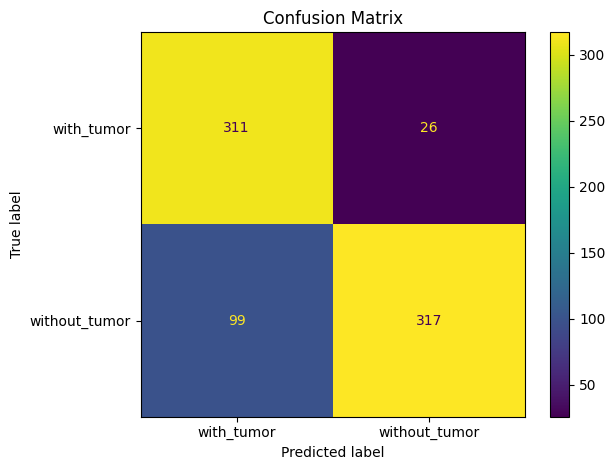

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.inference_mode():
        for X, y in dataloader:
            y_pred = model(X).squeeze(1)
            y_pred_class = (torch.sigmoid(y_pred) > 0.5).int()
            all_preds.extend(y_pred_class.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=list(class_dict.keys()))
    disp.plot()
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(model, test_dataloader)